# IN5450 - Project 1: Array Signal Processing

In this exercise we study diffraction from a line aperture using the Rayleigh–Sommerfeld integration formula and the array pattern (aperture smoothing function) of several linear arrays.

**Mandatory problems (IN5450):** 1–2, 4–9, 12–13.

All MATLAB code is provided in separate `.m` files and orchestrated by `run_all.m`. The provided functions `beampattern.m`, `analyzeBP.m`, and `R_S_LinAperture.m` are used throughout.

## Part 1: Diffraction from a Line Aperture

The Rayleigh–Sommerfeld diffraction integral propagates the aperture field to observation points in the half-space. The provided script `DiffLinAp.m` propagates a uniform pressure distribution from a line aperture of length $D = 20\lambda$ ($f_0 = 3$ MHz, $c = 1500$ m/s) centred at the origin to a set of observation points.

### Problem 1
Run `DiffLinAp.m`. Do the plots look as expected? Explain what you observe and why.

### Problem 2
Modify `DiffLinAp.m` to:
- Make a 2D image of the diffracted field for $x \in [-8, 8]$ cm and $z \in [5\lambda, 8 \text{ cm}]$.
- Plot the pressure along the $z$-axis ($x = 0$).
- Plot the response along a half-circle at $r = z_R$ (the near-field/far-field boundary).
- Plot the response along a half-circle at $r \gg z_R$.

### Answer - Problem 1

Running `DiffLinAp.m` propagates the uniform line aperture ($D = 20\lambda$, $f_0 = 3$ MHz) to a half-circle at $r = 5$ cm and plots the response.

![alt text](image-21.png)

**Near-field observation ($r = 5$ cm $\approx z_R$):**
The response shows a main lobe centred at broadside ($\phi = 0$) with noticeable ripple/sidelobes. Large oscillations and irregular structure are visible. This is expected because at ranges comparable to the Rayleigh distance $z_R = D^2/(4\lambda)$ we are still in the near-field region, where the field has not yet converged to its far-field angular pattern. The contributions from different parts of the aperture arrive with significantly differing phases, producing constructive/destructive interference that creates an irregular amplitude profile.

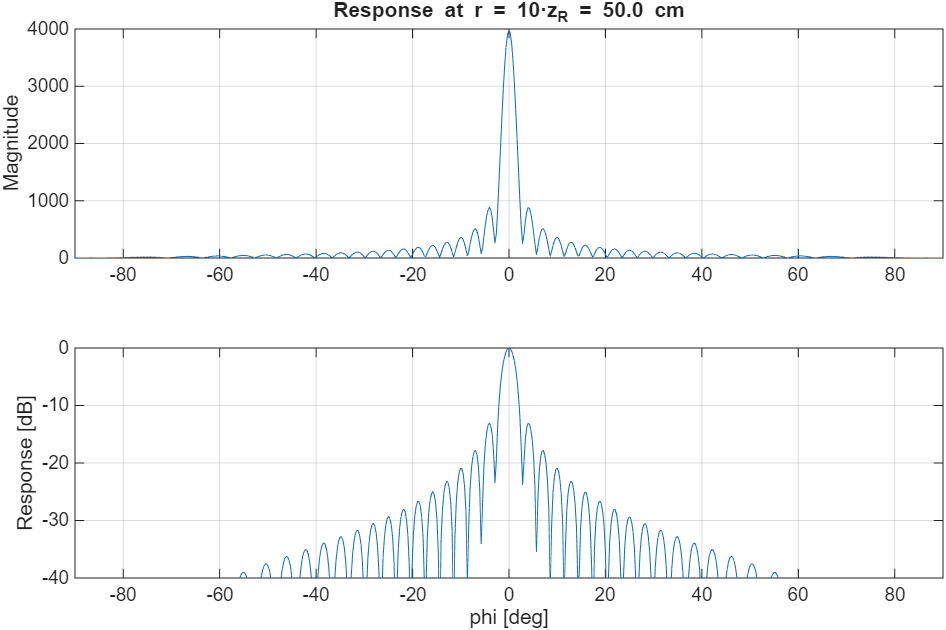

**Far-field observation ($r \gg z_R$):**
At large distances the angular response becomes smooth and resembles the expected $\mathrm{sinc}$-like pattern of a uniform aperture. The main lobe is well-defined and the sidelobes decay monotonically. In the far field the diffracted field is proportional to the spatial Fourier transform of the aperture distribution - a $\mathrm{sinc}$ function for a rectangular window.

In summary, the plots look as expected: the transition from near-field to far-field is clearly visible in the increasing smoothness of the angular response.

*The modified script is in `twaal_DiffLinAp.m`. It generates four figures: the 2D field image, the on-axis pressure, and the responses at the Rayleigh distance and 10× the Rayleigh distance.*

### Answer - Problem 2

**2D diffraction field** ($x \in [-8, 8]$ cm, $z \in [5\lambda, 8\text{ cm}]$):

![alt text](image-24.png)

The 2D image shows how the beam forms as we move away from the aperture. Close to the array (small $z$) the field is approximately confined to the aperture width $D$ and shows complex near-field interference. Further away the beam starts spreading and the familiar main-lobe / side-lobe structure emerges.

**On-axis pressure** ($x = 0$):

![alt text](image-23.png)

The on-axis amplitude oscillates in the near field due to path-length differences - different parts of the aperture contribute with varying phases that alternately constructively and destructively interfere. Beyond $z_R$ the oscillations cease and the pressure decays monotonically as $1/\sqrt{z}$ (cylindrical spreading for a line source).

**Normalised on-axis response** (corrected for $1/\sqrt{r}$ spreading):

![alt text](image-23-norm.png)

After correcting for the cylindrical spreading factor $1/\sqrt{r}$, the on-axis response oscillates in the near field but converges to an approximately constant value beyond $z_R$. The transition from oscillatory to constant behaviour provides an alternative, visually identifiable near-field/far-field boundary that is consistent with the analytically derived Fresnel limit $z_R = D^2/(4\lambda)$.

## Near/Far Field Limit for a Line Aperture

The maximum phase error from the Fresnel approximation at the aperture edge $x' = D/2$:

$$\Delta\phi_\text{max} = \frac{\pi D^2}{4\lambda z}$$

Setting $\Delta\phi_\text{max} = \pi/2$ (path difference $= \lambda/4$) gives the boundary:

$$\boxed{z_R = \frac{D^2}{4\lambda}}$$

This is the **Fresnel limit**. The more commonly seen $2D^2/\lambda$ (Rayleigh distance)
uses a stricter phase criterion and applies to 2D apertures.

---
**Reference:** S. Holm, *IN5450 Diffraction: from waves to signal processing*,
University of Oslo, 2019.
[Lecture notes](https://www.mn.uio.no/fysikk/english/people/aca/sverre/lecturenotes/2019-in5450-5-waves-signalprocessing.pdf)

**Response at $r = z_R$** (near-field / far-field boundary):
At the Rayleigh distance the angular response still shows some near-field artifacts - the sidelobes are not yet fully stabilised and ripples are visible in the main lobe. This is consistent with $z_R$ being only a *boundary*; the true far-field pattern only fully develops at distances well beyond $z_R$.

**Response at $r = 10 \cdot z_R$** (well into far field):
At $r = 50$ cm $= 10z_R$, the pattern is smooth and closely matches the theoretical $\mathrm{sinc}$ pattern of the uniform aperture. Sidelobes are clearly resolved and decay symmetrically on both sides. The first sidelobe is at approximately $-13.2$ dB relative to the main lobe, matching the known value for a rectangular window.

## Part 2: Array Pattern

The array pattern (aperture smoothing function) of an $M$-element array with positions $x_m$ and weights $w_m$ is

$$W(k_x) = \sum_{m=1}^{M} w_m \, e^{j k_x x_m}$$

The provided function `beampattern.m` computes this, and `analyzeBP.m` extracts the $-3$ dB / $-6$ dB mainlobe widths and maximum sidelobe level.

### Problem 4 - Grating Lobes
$M = 24$ elements, unity weights, uniform spacing $d = \lambda/4,\; \lambda/2,\; \lambda,\; 2\lambda$. Plot and discuss.

### Problems 5–8 - Weighting, Non-uniform Spacing, Steering
- **5:** Kaiser window ($\beta = 0$–$5$) on the $d = \lambda/2$ array. Report beamwidths, sidelobes, and WNG.
- **6:** Non-uniform "Case B" array (Hodjat & Hovanessian 1978). Compare with 4) and 5).
- **7:** Steering the Case B array. Plot extended $u \in [-2, 2]$ response.
- **8:** Beamwidth vs. steering angle for Case B.

*MATLAB code: `twaal_gratinglobes.m` (Problem 4), `twaal_element_weighting_and_spacing.m` (Problems 5–8).*

### Answer - Problem 4

![alt text](image-6.png)

The four subplots show the beampattern of a 24-element ULA with uniform weights for $d = \lambda/4$, $\lambda/2$, $\lambda$, and $2\lambda$.

**Key observations:**

- **$d = \lambda/4$:** The main lobe is very wide ($-3$ dB BW $\approx 8.5°$). No grating lobes appear in the visible region $u \in [-1,1]$ since $d < \lambda/2$. The array aperture is small ($L = 23 \cdot \lambda/4 = 5.75\lambda$), which explains the poor angular resolution.

- **$d = \lambda/2$:** The main lobe narrows to $\approx 4.2°$ since the aperture doubles. Still no grating lobes - half-wavelength spacing is the maximum spacing that avoids grating lobes for broadside steering. This is the classical design criterion. Maximum sidelobe level is $-13.2$ dB (the well-known uniform window value).

- **$d = \lambda$:** The main lobe is even narrower, but a grating lobe now appears at $u = \pm 1$ (i.e. $\theta = \pm 90°$) at the edge of the visible region. Grating lobes appear when $d \geq \lambda$, since the spatial sampling does not satisfy the Nyquist criterion.

- **$d = 2\lambda$:** Multiple grating lobes appear within the visible region. They are replicas of the main lobe at $u = \pm 0.5, \pm 1.0$, i.e., at intervals of $\lambda/d = 0.5$ in $u$-space. These are indistinguishable from the main lobe and make unambiguous direction finding impossible.

**Trade-off:** Increasing $d$ yields a larger aperture (hence narrower main lobe and better resolution), but grating lobes enter the visible region once $d > \lambda / 2$. The $d = \lambda/2$ spacing is the optimal compromise for an unsteered ULA.

*See the combined discussion of Problems 5–8 below. The Case B element positions are defined in the code as:*
```matlab
n = 1:12;
d = 1/2; % lambda/2
e_n = [-0.017 -0.538 -0.617 -1.0 -1.142 -1.372 ...
       -1.487 -1.555 -1.537 -1.3 -0.772 -0.242];
d_n = (n + e_n)*d;
ElPos = [-fliplr(d_n) d_n];
```

### Answer - Problem 5

Kaiser windows were applied to the $M = 24$, $d = \lambda/2$ array for $\beta = 0$ (uniform) to $\beta = 5$:

| $\beta$ | $-3$ dB BW (°) | $-6$ dB BW (°) | Max SL (dB) | WNG (dB) |
|---------|-----------------|-----------------|-------------|----------|
| 0.0 | 4.21 | 5.74 | −13.2 | 13.8 |
| 0.5 | 4.25 | 5.81 | −13.6 | 13.8 |
| 1.0 | 4.37 | 5.97 | −14.7 | 13.8 |
| 1.5 | 4.55 | 6.23 | −16.6 | 13.7 |
| 2.0 | 4.78 | 6.57 | −19.0 | 13.6 |
| 2.5 | 5.03 | 6.94 | −21.8 | 13.4 |
| 3.0 | 5.33 | 7.35 | −25.0 | 13.2 |
| 3.5 | 5.61 | 7.76 | −28.3 | 12.9 |
| 4.0 | 5.88 | 8.18 | −31.7 | 12.7 |
| 4.5 | 6.16 | 8.57 | −34.9 | 12.5 |
| 5.0 | 6.43 | 8.96 | −38.0 | 12.3 |

**White noise gain (WNG)** is computed as $\text{WNG} = |\sum w_m|^2 / \sum |w_m|^2 = 1/\sum w_m^2$ (since $\sum w_m = 1$). It quantifies the array's ability to suppress spatially white noise relative to a single sensor. Uniform weighting maximises WNG at $10\log_{10}(M) = 13.8$ dB.

**Advantage of Kaiser window:** Dramatically reduces sidelobe level (from $-13$ dB to $-38$ dB over the tested range), which is critical for rejecting interferers and reducing spatial leakage.

**Disadvantage:** The main lobe broadens (from $4.2°$ to $6.4°$), reducing angular resolution. WNG drops slightly because the tapered weights amplify noise from the less-weighted edge elements less, but the array becomes less effective at suppressing uncorrelated sensor noise.

### Answer - Problem 6

The non-uniform "Case B" element positions (from Hodjat & Hovanessian 1978) use $M = 24$ elements with **unity weights** and a slightly larger aperture than the $\lambda/2$ ULA:

| Array | Aperture (mm) | WNG (dB) | $-3$ dB BW (°) | $-6$ dB BW (°) | Max SL (dB) |
|-------|-------------|----------|-----------------|-----------------|-------------|
| Uniform $d = \lambda/2$ | 5.8 | 13.8 | 4.21 | 5.74 | −13.2 |
| Kaiser $\beta = 3$ | 5.8 | 13.2 | 5.33 | 7.35 | −25.0 |
| Case B (non-uniform) | 5.9 | 13.8 | 4.55 | 6.25 | −17.9 |

**Discussion:** Case B achieves $\approx 5$ dB sidelobe improvement over the uniform array while retaining maximum WNG (since unity weights are used). The main lobe broadens only slightly ($4.55°$ vs $4.21°$). Compared to Kaiser $\beta = 3$, Case B has higher sidelobes ($-17.9$ vs $-25.0$ dB) but a narrower beam and full WNG. This demonstrates that optimising element *positions* rather than *weights* offers a different trade-off: one can reduce sidelobes without sacrificing noise robustness. The non-uniform spacing also breaks the periodicity that causes grating lobes, which is important when the aperture is large relative to $\lambda$.

**Figures for Problem 5:**
![alt text](image-7.png)

**Figures for Problem 6:**
![alt text](image-8.png)

### Answer - Problem 7

**Unsteered, extended $u \in [-2, 2]$:**
![alt text](image-9.png)

The unsteered Case B array is plotted over $u = \sin\theta \in [-2, 2]$ (i.e., beyond the visible region $|u| \leq 1$). Outside the visible region we see the periodic continuation of the beampattern. For a uniform array with spacing $d$, the beampattern repeats with period $\lambda / d$ in $u$-space. The non-uniform element positions of Case B break this strict periodicity, which means the "invisible" side-lobes are not exact replicas. However, structure is still visible outside $|u| = 1$.

The key point: when steering is applied, these structures shift and can enter the visible region, creating grating-lobe-like artefacts. For uniformly spaced arrays with $d > \lambda/2$, the periodic repetition guarantees grating lobes upon steering. The non-uniform Case B reduces but does not eliminate this risk.

**Steered responses** ($\theta_s = 0°, 20°, 40°, 60°$):
![alt text](image-10.png)

As $\theta_s$ increases, the main lobe broadens (proportional to $1/\cos\theta_s$) and sidelobes grow. At $\theta_s = 60°$ the main lobe is significantly wider and sidelobe levels are elevated. This effect occurs for *all* arrays tested - it is a fundamental property of linear arrays where the effective projected aperture shrinks as $D_\text{eff} = D \cos\theta_s$.

### Answer - Problem 8

![alt text](image-11.png)

**Beamwidth vs. steering angle (Case B):**

In the upper plot, the $-3$ dB and $-6$ dB beamwidths in degrees both increase with steering angle. The broadening follows approximately $\Delta\theta \propto 1/\cos\theta_s$, which can be understood from the array factor: the beamwidth in $u$-space ($\Delta u$) remains nearly constant, but mapping to angle via $\theta = \arcsin(u)$ stretches the beamwidth as $\Delta\theta \approx \Delta u / \cos\theta_s$.

In the lower plot, the beamwidth in $\sin\theta$ remains approximately constant as a function of steering angle, confirming that the broadening in degrees is a purely geometric (projection) effect. The array's resolving power in direction-cosine space is independent of steering direction.

This result isn't unique to Case B - it holds for any linear array, though sidelobe behaviour during steering varies between uniform, tapered, and non-uniform designs.

### Summary of Weighting/Spacing Trade-offs

The uniform array exhibits $-13.2$ dB sidelobes - a consequence of the sharp amplitude discontinuity at the aperture edges (the spatial analogue of the Gibbs phenomenon).

**Kaiser window:** Tapering with a Kaiser window smoothly reduces the edge discontinuity. Each $\approx 12$ dB of sidelobe suppression costs roughly $1°$ of main-lobe broadening. The WNG penalty is modest ($13.8 \to 12.3$ dB over $\beta = 0 \to 5$) because the weights remain relatively smooth.

**Non-uniform spacing (Case B):** By optimising element *positions* rather than weights, Case B achieves $-17.9$ dB sidelobes with unity weights. This preserves the full WNG ($13.8$ dB) - a significant advantage in noise-limited scenarios. The trade-off is that design of optimal positions is more complex and the improvement ceiling is lower than what heavy tapering can achieve.

In practice, the choice between tapering and non-uniform spacing depends on the application: if noise robustness and WNG are critical, non-uniform spacing is preferred; if very low sidelobes are required (e.g. for weak-target detection), Kaiser or similar windows are appropriate despite the WNG penalty.

## Part 3: Array Thinning

### Problem 9
An $M = 101$ element ULA with $d = \lambda/2$ is thinned by randomly selecting $N$ active elements (keeping the outer two). 200 realisations are generated for $N = 25, 50, 75$ and statistics of beamwidth, maximum and mean sidelobe levels are computed. Results are compared with the dense array and optimal arrays from Hopperstad & Holm (1999).

*MATLAB code: `twaal_thinning.m`*

### Answer - Problem 9

200 random thinned-array realisations were generated for $N = 25, 50, 75$ active elements (from $M = 101$ possible positions at $d = \lambda/2$). Statistics of beamwidth, max sidelobe, and mean sidelobe level:

| $N$ | $-3$ dB BW (°) | $\sigma_\text{BW}$ (°) | Mean max SL (dB) | $\sigma_\text{SL}$ (dB) | Mean SL (dB) |
|-----|-----------------|----------------------|-------------------|------------------------|--------------|
| 25 | 0.96 | 0.07 | −7.6 | 1.0 | −17.4 |
| 50 | 0.98 | 0.04 | −11.6 | 1.3 | −22.0 |
| 75 | 0.99 | 0.03 | −13.0 | 1.6 | −26.4 |
| 101 (dense) | 1.00 | - | −13.3 | - | −40.7 |

**Observations:**
- **Beamwidth** is essentially unchanged across thinning levels ($\approx 1°$). This confirms that the beamwidth of a thinned array is determined by the total aperture extent, not the number of active elements - the outer elements are always kept.
- **Max sidelobe level** improves significantly as $N$ increases. For $N = 25$ (75% elements removed) the worst sidelobe is only $-7.6$ dB on average, compared to $-13.3$ dB for the dense array. At $N = 75$ we nearly recover the dense-array performance.
- **Mean sidelobe level** drops roughly as $10\log_{10}(N/M)$: fewer active elements means the "background" sidelobe floor rises because the missing elements contribute random-phase-like errors.

**Comparison with Hopperstad & Holm optimal arrays** ($N = 25$):

| Design | $-3$ dB BW (°) | Max SL (dB) | Mean SL (dB) |
|--------|-----------------|-------------|--------------|
| Random thinning (avg.) | 0.96 | −7.6 | −17.4 |
| H&H Fig 2 (reference) | 1.41 | −12.0 | −16.9 |
| H&H Fig 3 (min BW) | 1.18 | −12.1 | −16.2 |
| H&H Fig 4 (min SL) | 1.43 | −12.4 | −16.8 |

The simulated-annealing-optimised arrays achieve $\approx 4{-}5$ dB better max sidelobe levels than random thinning at the same element count, at the cost of slightly wider main lobes. The optimised designs sacrifice some aperture utilisation (not all outer elements are at the extremes of the grid) to spread the sidelobes more uniformly. This illustrates that deterministic optimisation can substantially outperform random thinning for sidelobe control.

**Thinned arrays - 25 of 101 elements (200 realisations):**
![alt text](image-12.png)

**Thinned arrays - 50 of 101 elements:**
![alt text](image-13.png)

**Thinned arrays - 75 of 101 elements:**
![alt text](image-14.png)

In the overlay plots, the red line shows the dense (all 101 elements) reference. The spread of the grey curves illustrates the variability of random thinning. As $N$ increases, the spread narrows and the sidelobe floor drops, converging toward the dense-array pattern.

**Optimal sparse arrays (Hopperstad & Holm) vs. dense reference:**
![alt text](image-16.png)

The optimised 25-element arrays (coloured) show significantly lower peak sidelobes than any single random realisation, demonstrating the benefit of intelligent element placement.

## Part 4: Element Directivity

### Problem 12
Revisit the $M = 24$ arrays with $d = \lambda$ and $d = 2\lambda$. Include the element response of a rectangular element of size $d$ and compare with the point-source results from Problem 4.

### Problem 13
Apply steering to the arrays with element directivity and observe the effect on grating lobes.

*MATLAB code: `twaal_element_directivity.m`*

### Answer - Problem 12

Each element is modelled as a rectangular piston of width $d$, so the element response is

$$H_e(k_x) = \mathrm{sinc}\!\left(\frac{k_x d}{2\pi}\right) = \frac{\sin(k_x d/2)}{k_x d/2}$$

The total array response is the product $W_\text{total}(k_x) = W_\text{array}(k_x) \cdot H_e(k_x)$.

![alt text](image-19.png)

**$d = \lambda$:** The element response has its first zero at $u = \pm 1$ ($\theta = \pm 90°$), coinciding with the grating lobe position. This suppresses the grating lobe very effectively at broadside. The element envelope spans the entire visible region $|u| \leq 1$, so the total response closely follows the array-factor main lobe and sidelobes with only mild roll-off at large angles.

**$d = 2\lambda$:** The element response has zeros at $u = \pm 0.5, \pm 1.0$, which happen to coincide with the grating lobe positions, suppressing them at broadside. However, the narrower element envelope (first zero at $u = 0.5$, $-3$ dB at $u \approx 0.22$) significantly attenuates the response beyond $\approx 13°$. The total pattern is effectively confined to a narrow angular range around broadside. While grating lobes are suppressed, the usable field of view is greatly reduced.

**Key observation:** When the element width equals the inter-element spacing, the element response zeros coincide with the grating lobe positions at broadside. Larger elements have a narrower angular acceptance, which limits the array's usable scan range.

### Answer - Problem 13

![alt text](image-20.png)

When steering is applied, the array factor shifts in $u$-space by $\sin\theta_s$, but the element response $H_e(k_x)$ remains fixed (the physical elements do not rotate). This breaks the alignment between grating lobes and element-response zeros.

**$d = \lambda$:** At broadside the grating lobe at $u = \pm 1$ is suppressed. As $\theta_s$ increases, the grating lobes shift away from the element zeros, causing them to reappear. The element envelope still provides some attenuation, but the suppression degrades progressively. By $\theta_s = 60°$, a grating lobe is partially visible.

**$d = 2\lambda$:** The narrower element envelope ($-3$ dB at $u \approx 0.22$) means the steered main lobe is itself attenuated at large steering angles, while a grating lobe that shifts closer to broadside sits near the element-pattern maximum. Already at $\theta_s = 20°$, the first grating lobe near broadside can exceed the steered main lobe in amplitude - the element directivity now works *against* the intended beam direction.

**Conclusion:** Element directivity provides good grating-lobe suppression at broadside, but the benefit vanishes with steering. For $d > \lambda/2$, the usable scan range is limited: the array can only steer as far as the grating lobes remain within the attenuated region of the element pattern. For $d = \lambda$ this gives a reasonable $\pm 30°{-}40°$ scan range; for $d = 2\lambda$ the usable range is very narrow ($\lesssim 10°$).

## Deliverables

- Electronic presentation (≤ 15–20 slides, ≤ 15 min)
- Source code (all `.m` files)
- Runtime example (`runtime_example.txt` generated by `run_all.m`)
- Some essential code on slides

## Runtime Example

All tasks are executed by `run_all.m`, which saves console output to `runtime_example.txt`:

```
==============================================
  IN5450 Coursework - Runtime example
==============================================

--- Tasks 1-2: Diffraction from line aperture ---

--- Task 4: Grating lobes ---
d = λ/4:  -3dB BW = 8.45°,  -6dB BW = 11.51°,  max SL = -13.2 dB
d = λ/2:  -3dB BW = 4.21°,  -6dB BW = 5.74°,   max SL = -13.2 dB
d = λ:    analyzeBP failed (grating lobe at edge of visible region)
d = 2λ:   analyzeBP failed (grating lobe at edge of visible region)

--- Tasks 5-8: Element weighting and spacing ---
beta    -3dB BW(°)    -6dB BW(°)    max SL(dB)    WNG(dB)
0.0     4.21          5.74          -13.2         13.8
...
5.0     6.43          8.96          -38.0         12.3

Array             Aperture(mm)  WNG(dB)  -3dB(°)  -6dB(°)  maxSL(dB)
Uniform d=λ/2     5.8          13.8     4.21     5.74     -13.2
Kaiser β=3        5.8          13.2     5.33     7.35     -25.0
Case B            5.9          13.8     4.55     6.25     -17.9

--- Task 9: Thinned arrays ---
N=25:   BW=0.96±0.07°, max SL=-7.6±1.0 dB,  mean SL=-17.5 dB
N=50:   BW=0.98±0.05°, max SL=-11.4±1.3 dB, mean SL=-22.1 dB
N=75:   BW=0.99±0.03°, max SL=-13.1±1.4 dB, mean SL=-26.3 dB
Dense:  BW=1.00°,       max SL=-13.3 dB,     mean SL=-40.7 dB

--- Tasks 12-13: Element directivity ---

==============================================
  All tasks complete.
==============================================
```